In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.DataFrame({
    "hours": [1, 2, 3, 4, 5],     # 공부시간
    "score": [50, 55, 65, 70, 75] # 점수
})

# 1. 독립변수(X)와 종속변수(y) 나누기
# 독립변수 X는 2차원 형태(DataFrame)여야 하므로 리스트 형태로 대괄호를 두 번 감쌉니다.
X = df[["hours"]]   # 독립변수
y = df["score"]     # 종속변수

# 2. 선형회귀 모델 불러오기
from sklearn.linear_model import LinearRegression

# 3. 모델 객체 생성하기
model = LinearRegression() # 회귀분석 모형

# 4. 모델 학습시키기
model.fit(X, y)

# 5. 학습된 모델로 예측하기
y_pred = model.predict(X)
print("기존 데이터 예측값:", y_pred)

# 6. 기울기(가중치/계수) 확인하기
# 모델 속성이므로 이름 끝에 언더스코어(_)가 붙습니다.
print("기울기(coef_):", model.coef_)

# 7. 절편(편향) 확인하기
print("절편(intercept_):", model.intercept_)

# 8. 공부시간이 6시간일 때 점수 예측하기
# 2차원 입력 형태로 [[6]]을 전달합니다.
pred = model.predict([[6]])
print("6시간 공부 시 예상 점수:", pred[0])

기존 데이터 예측값: [50.  56.5 63.  69.5 76. ]
기울기(coef_): [6.5]
절편(intercept_): 43.5
6시간 공부 시 예상 점수: 82.5


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


[문제 1] 데이터 로드 및 기초 탐색

1. 상위 5개 행:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

2. 요약 통계량:
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000

[문제 2] EDA 시각화 작성


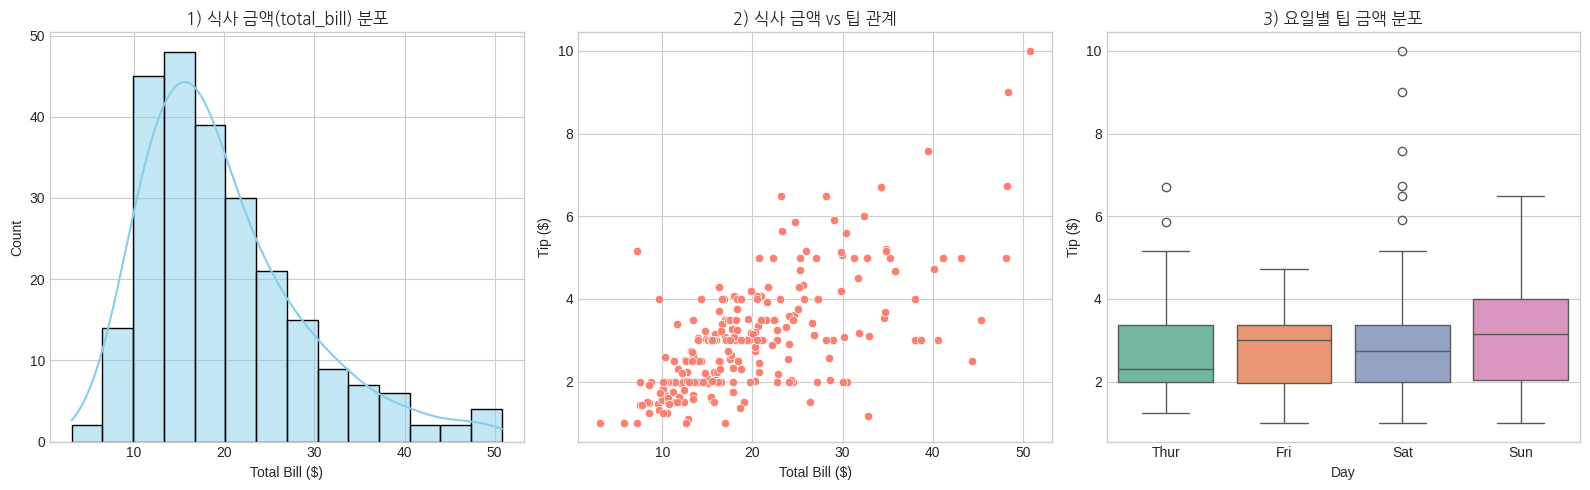


[문제 3] 파생변수 생성 및 범주형 원-핫 인코딩

인코딩 후 데이터 상위 5개 행:
   total_bill   tip  size  price_per_person  sex_Female  smoker_No  day_Fri  \
0       16.99  1.01     2          8.495000           1          1        0   
1       10.34  1.66     3          3.446667           0          1        0   
2       21.01  3.50     3          7.003333           0          1        0   
3       23.68  3.31     2         11.840000           0          1        0   
4       24.59  3.61     4          6.147500           1          1        0   

   day_Sat  day_Sun  time_Dinner  
0        0        1            1  
1        0        1            1  
2        0        1            1  
3        0        1            1  
4        0        1            1  

[문제 4] 데이터 스케일링 및 비교 시각화


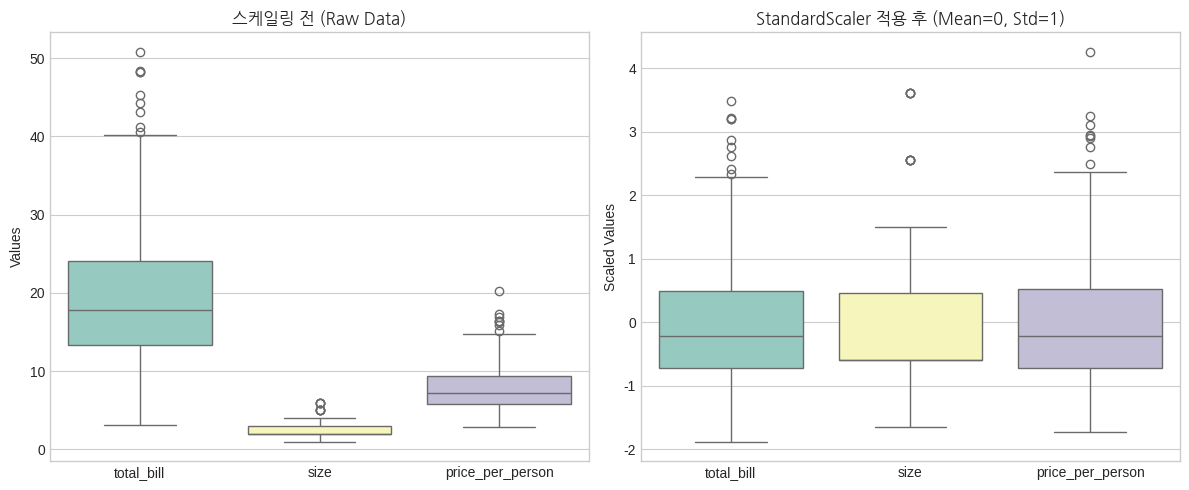


[문제 5] 독립변수/종속변수 분리 및 Train-Test 데이터 분할
학습 데이터 크기 (X_train_sm): (170, 10)
테스트 데이터 크기 (X_test_sm) : (74, 10)

[문제 6] statsmodels OLS 모델 학습 및 성능 평가
Train R² Score : 0.4962
Test R² Score  : 0.2931
Test RMSE      : $0.9653

[주요 변수별 회귀계수 및 유의확률]
                  Coefficient  P-Value
const                  2.9666   0.0000
total_bill             1.1968   0.0004
size                   0.0046   0.9860
price_per_person      -0.2952   0.2824
sex_Female            -0.0848   0.6318
smoker_No              0.2769   0.1344
day_Fri                0.2087   0.6419
day_Sat                0.0513   0.9250
day_Sun                0.0257   0.9623
time_Dinner           -0.1599   0.7533

[문제 7] 신규 데이터 팁 금액 예측
신규 손님 정보: total_bill=$50.0 | size=4명 | Female | Non-Smoker | Sun | Dinner
-> 예상 팁(Tip) 금액: $6.63


In [ ]:
# ==============================================================================
# 1. 한글 폰트 설치 및 패키지 불러오기 (한글 깨짐 완벽 방지)
# ==============================================================================
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 나눔고딕 폰트 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

# ==============================================================================
# [문제 1] 데이터 로드 및 기초 탐색
# ==============================================================================
print("="*60)
print("[문제 1] 데이터 로드 및 기초 탐색")
print("="*60)

df = sns.load_dataset('tips') # sns -> seaborn 시각화 툴, 시각화하는 툴 (matplotlib, seaborn)

print("\n1. 상위 5개 행:")
print(df.head())

print("\n2. 요약 통계량:")
print(df.describe())


# ==============================================================================
# [문제 2] 탐색적 데이터 분석(EDA) 그래프 작성 및 분석
# ==============================================================================
print("\n" + "="*60)
print("[문제 2] EDA 시각화 작성")
print("="*60)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 3, figsize=(16, 5)) # 1행 3열 가로 16인치, 세로 5인치

# 1) 식사 금액(total_bill) 히스토그램
sns.histplot(df['total_bill'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('1) 식사 금액(total_bill) 분포', fontproperties=font_prop, fontsize=12)
axes[0].set_xlabel('Total Bill ($)')
axes[0].set_ylabel('Count')

# 2) 식사 금액(total_bill)과 팁(tip)의 산점도
sns.scatterplot(x='total_bill', y='tip', data=df, ax=axes[1], color='salmon')
axes[1].set_title('2) 식사 금액 vs 팁 관계', fontproperties=font_prop, fontsize=12)
axes[1].set_xlabel('Total Bill ($)')
axes[1].set_ylabel('Tip ($)')

# 3) 요일(day)별 팁(tip) 금액 박스플롯 (FutureWarning 방지를 위해 hue 지정)
sns.boxplot(x='day', y='tip', hue='day', data=df, ax=axes[2], palette='Set2', legend=False)
axes[2].set_title('3) 요일별 팁 금액 분포', fontproperties=font_prop, fontsize=12)
axes[2].set_xlabel('Day')
axes[2].set_ylabel('Tip ($)')

plt.tight_layout()
plt.show()

"""
[EDA 인사이트 요약]
1. 식사 금액(total_bill)은 오른쪽으로 긴 꼬리를 갖는 비대칭 분포를 보이며, 주로 $10~$20 구간에 집중되어 있습니다.
2. 식사 금액이 늘어날수록 팁 금액도 함께 증가하는 명확한 양(+)의 선형 관계를 확인할 수 있습니다.
3. 요일별로는 일요일(Sun)과 토요일(Sat) 등 주말의 팁 금액 중앙값 및 상위 범위가 평일(Thur, Fri)보다 다소 높게 형성되는 경향을 보입니다.
"""


# ==============================================================================
# [문제 3] 파생변수 생성 및 범주형 원-핫 인코딩
# ==============================================================================
print("\n" + "="*60)
print("[문제 3] 파생변수 생성 및 범주형 원-핫 인코딩")
print("="*60)

# 파생변수 생성
df['price_per_person'] = df['total_bill'] / df['size']

# 원-핫 인코딩 (drop_first=True)
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'day', 'time'], drop_first=True, dtype=int)

# 데이터 분석할때 숫자로 변경해야 처리가 됨 (원핫 인코딩하는 이유)
# ex)
# 혈액형  A형  B형  O형  AB형
# A     1    0    0   0
# B     0    1    0   0
# O     0    0    1   0
# AB    0    0    0   1

print("\n인코딩 후 데이터 상위 5개 행:")
print(df_encoded.head())


# ==============================================================================
# [문제 4] 데이터 스케일링 및 비교 시각화
# ==============================================================================
print("\n" + "="*60)
print("[문제 4] 데이터 스케일링 및 비교 시각화")
print("="*60)

scale_cols = ['total_bill', 'size', 'price_per_person']

# 스케일링 전 데이터 복사
X_before_scale = df_encoded[scale_cols].copy()

# StandardScaler 적용 (스케일링 방법 중 1)
# 변수별 평균을 0, 표준편차를 1로 변환하여 서로 다른 변수의 단위와 크기를 맞춤
# 스케일링 -> 변수의 단위 조절
scaler = StandardScaler()
X_after_scale = pd.DataFrame(
    scaler.fit_transform(X_before_scale),
    columns=scale_cols
)

# 박스플롯 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=X_before_scale, ax=axes[0], palette='Set3')
axes[0].set_title('스케일링 전 (Raw Data)', fontproperties=font_prop, fontsize=12)
axes[0].set_ylabel('Values')

sns.boxplot(data=X_after_scale, ax=axes[1], palette='Set3')
axes[1].set_title('StandardScaler 적용 후 (Mean=0, Std=1)', fontproperties=font_prop, fontsize=12)
axes[1].set_ylabel('Scaled Values')

plt.tight_layout()
plt.show()

# 스케일링 결과를 원본 데이터프레임에 반영
df_encoded[scale_cols] = X_after_scale


# ==============================================================================
# [문제 5] 데이터 분할 및 statsmodels 전용 절편(const) 추가
# ==============================================================================
print("\n" + "="*60)
print("[문제 5] 독립변수/종속변수 분리 및 Train-Test 데이터 분할")
print("="*60)

X = df_encoded.drop(columns=['tip'])
y = df_encoded['tip']

# 학습용, 검증용으로 나누는 이유 - 예) 모의고사 기출 80퍼 내고 새로운 문제 20퍼 내는 것 처럼

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)

# random_state -> 데이터를 랜덤하게 나누는 결과를 매번 동일하게 고정하는 값
# 숫자 자체에는 특별한 의미가 X, 같은 숫자를 사용하면 같은 분할 결과가 나옴

# statsmodels 절편(const) 추가
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test, has_constant='add')

print(f"학습 데이터 크기 (X_train_sm): {X_train_sm.shape}")
print(f"테스트 데이터 크기 (X_test_sm) : {X_test_sm.shape}")


# ==============================================================================
# [문제 6] statsmodels OLS 모델 학습 및 성능 평가
# ==============================================================================
print("\n" + "="*60)
print("[문제 6] statsmodels OLS 모델 학습 및 성능 평가")
print("="*60)

model = sm.OLS(y_train, X_train_sm).fit()
#         모델    종속        독립      학습

y_pred_train = model.predict(X_train_sm)
y_pred_test = model.predict(X_test_sm)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
# 모향의 성능 측정
# R^2 1.0이면 완전히 일치

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
#                 평균제곱오차
# 예시)
# 실제    100   90
# 예측    90    100
# 오차    10    -10
#오차가 작을수록 성능이 좋음

print(f"Train R² Score : {train_r2:.4f}") # 모형의 설명력 1.0 (오차가 없다는 의미, 1.0이 가까울수록 좋은 모델)
print(f"Test R² Score  : {test_r2:.4f}")
print(f"Test RMSE      : ${rmse:.4f}") # 오차의 크기 (작을 수록 좋은 모델)

coef_summary = pd.DataFrame({
    'Coefficient': model.params,
    'P-Value': model.pvalues
})
print("\n[주요 변수별 회귀계수 및 유의확률]")
print(coef_summary.round(4))

# Coefficient(회귀계수): 해당 변수가 1 증가할 때 예측값이 얼마나 변하는지 나타냄
# 양수면 예측값 증가, 음수면 예측값 감소

# P-Value(유의확률): 해당 변수의 회귀계수가 실제로 0인지 검정하는 값
# 일반적으로 0.05보다 작으면 통계적으로 유의하다고 판단
# 0.05보다 크다고 바로 제거하지 않고, 변수의 의미·다중공선성·모델 성능 등을 함께 확인
# 변수를 제거한 뒤 Test R², RMSE 등이 개선되는지도 비교하여 최종 판단

# ==============================================================================
# [문제 7] 신규 데이터 정확한 인코딩 매핑 및 팁(Tip) 예측
# ==============================================================================
print("\n" + "="*60)
print("[문제 7] 신규 데이터 팁 금액 예측")
print("="*60)

# 1. 신규 데이터 수동 인코딩 (X.columns 구조와 100% 일치하도록 구성)
# 조건: total_bill=$50.0 | size=4 | Female | Non-Smoker | Sun | Dinner
# drop_first=True 적용 기준:
# sex_Female (여성이므로 1)
# smoker_No (비흡연자이므로 1)
# day_Sun (일요일이므로 1, 나머지는 0)
# time_Dinner (저녁이므로 1)

new_guest_dict = {
    'total_bill': 50.0,
    'size': 4,
    'price_per_person': 50.0 / 4,
    'sex_Female': 1,
    'smoker_No': 1,
    'day_Fri': 0,
    'day_Sat': 0,
    'day_Sun': 1,
    'time_Dinner': 1
}

# X_train의 컬럼 순서 및 구성에 정확히 동기화
new_guest_df = pd.DataFrame([new_guest_dict])[X.columns]

# 2. 수치형 변수 스케일링
new_guest_scaled = new_guest_df.copy()
new_guest_scaled[scale_cols] = scaler.transform(new_guest_df[scale_cols])

# 모델이 스케일링된 수치형 변수로 학습되었으므로
# 신규 데이터도 학습 때 사용한 동일한 scaler로 변환
# 신규 데이터에는 fit하지 않고 transform만 적용

# 3. statsmodels 전용 절편 추가 및 예측
new_guest_sm = sm.add_constant(new_guest_scaled, has_constant='add')
predicted_tip = model.predict(new_guest_sm).values[0]

print("신규 손님 정보: total_bill=$50.0 | size=4명 | Female | Non-Smoker | Sun | Dinner")
print(f"-> 예상 팁(Tip) 금액: ${predicted_tip:.2f}")